## importing libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## loading dataset

In [4]:
df= pd.read_csv("features_30_sec.csv")
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 1000 non-null   object 
 1   length                   1000 non-null   int64  
 2   chroma_stft_mean         1000 non-null   float64
 3   chroma_stft_var          1000 non-null   float64
 4   rms_mean                 1000 non-null   float64
 5   rms_var                  1000 non-null   float64
 6   spectral_centroid_mean   1000 non-null   float64
 7   spectral_centroid_var    1000 non-null   float64
 8   spectral_bandwidth_mean  1000 non-null   float64
 9   spectral_bandwidth_var   1000 non-null   float64
 10  rolloff_mean             1000 non-null   float64
 11  rolloff_var              1000 non-null   float64
 12  zero_crossing_rate_mean  1000 non-null   float64
 13  zero_crossing_rate_var   1000 non-null   float64
 14  harmony_mean             

In [6]:
df.shape

(1000, 60)

In [7]:
df.isnull().sum()

filename                   0
length                     0
chroma_stft_mean           0
chroma_stft_var            0
rms_mean                   0
rms_var                    0
spectral_centroid_mean     0
spectral_centroid_var      0
spectral_bandwidth_mean    0
spectral_bandwidth_var     0
rolloff_mean               0
rolloff_var                0
zero_crossing_rate_mean    0
zero_crossing_rate_var     0
harmony_mean               0
harmony_var                0
perceptr_mean              0
perceptr_var               0
tempo                      0
mfcc1_mean                 0
mfcc1_var                  0
mfcc2_mean                 0
mfcc2_var                  0
mfcc3_mean                 0
mfcc3_var                  0
mfcc4_mean                 0
mfcc4_var                  0
mfcc5_mean                 0
mfcc5_var                  0
mfcc6_mean                 0
mfcc6_var                  0
mfcc7_mean                 0
mfcc7_var                  0
mfcc8_mean                 0
mfcc8_var     

In [8]:
df = df.drop(columns=['filename'])
df


,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,3805.839606,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,3550.522098,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,3042.260232,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,2184.745799,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,3579.757627,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,661794,0.352063,0.080487,0.079486,0.000345,2008.149458,282174.689224,2106.541053,88609.749506,4253.557033,...,45.050526,-13.289984,41.754955,2.484145,36.778877,-6.713265,54.866825,-1.193787,49.950665,rock
996,661794,0.398687,0.075086,0.076458,0.000588,2006.843354,182114.709510,2068.942009,82426.016726,4149.338328,...,33.851742,-10.848309,39.395096,1.881229,32.010040,-7.461491,39.196327,-2.795338,31.773624,rock
997,661794,0.432142,0.075268,0.081651,0.000322,2077.526598,231657.968040,1927.293153,74717.124394,4031.405321,...,33.597008,-12.845291,36.367264,3.440978,36.001110,-12.588070,42.502201,-2.106337,29.865515,rock
998,661794,0.362485,0.091506,0.083860,0.001211,1398.699344,240318.731073,1818.450280,109090.207161,3015.631004,...,46.324894,-4.416050,43.583942,1.556207,34.331261,-5.041897,47.227180,-3.590644,41.299088,rock


In [9]:
# Replace infinite values if any
df.replace([np.inf, -np.inf], 0, inplace=True)

In [10]:
df.columns

Index(['length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var',
       'spectral_centroid_mean', 'spectral_centroid_var',
       'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean',
       'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
       'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo',
       'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
       'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
       'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
       'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
       'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
       'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
       'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
       'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var',
       'label'

In [11]:
genres = df['label'].unique()
print(genres)

['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23840\45946874.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


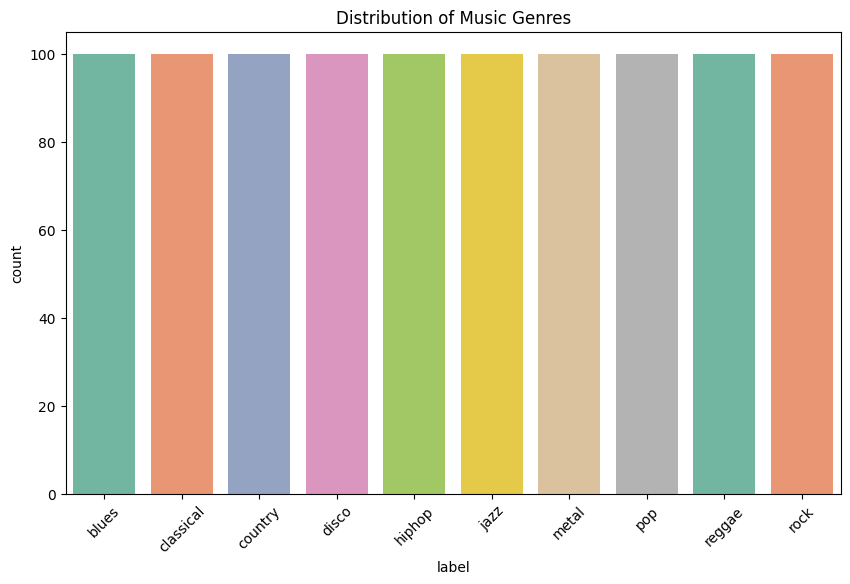

In [12]:
#  Label (Genre) distribution
plt.figure(figsize=(10,6))
sns.countplot(x='label', data=df, palette='Set2')
plt.xticks(rotation=45)
plt.title("Distribution of Music Genres")
plt.show()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23840\669416969.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='tempo', data=df, palette='Set3')


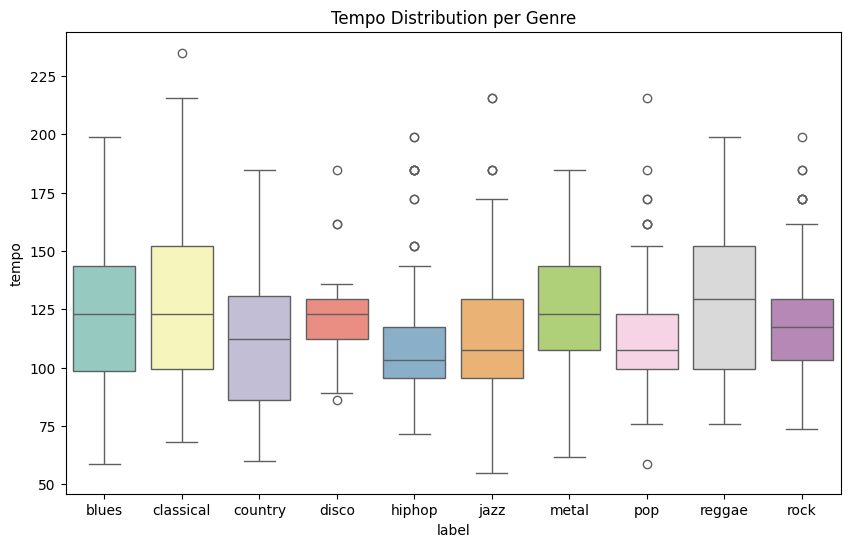

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(x='label', y='tempo', data=df, palette='Set3')
plt.title("Tempo Distribution per Genre")
plt.show()

In [14]:
#  Encode target labels (LabelEncoder)

from sklearn.preprocessing import LabelEncoder

l= LabelEncoder()
df['label'] = l.fit_transform(df['label'])


In [15]:
X = df.drop('label', axis=1)
y = df['label']


In [16]:
#  Train-Test Split

from sklearn.model_selection import train_test_split

# Split into 80% train, 20% test, stratify by labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (800, 58) (800,)
Test shape: (200, 58) (200,)


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### LOGISTIC REGRESSION

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
l_acc=accuracy_score(y_test, y_pred)
l_con=confusion_matrix(y_test, y_pred)
print("Logistic Regression Accuracy:",l_acc )
print("Logistic Regression confusion matrix:", confusion_matrix(y_test, y_pred))


Logistic Regression Accuracy: 0.74
Logistic Regression confusion matrix: [[15  0  1  0  0  2  0  0  1  1]
 [ 0 19  0  0  0  1  0  0  0  0]
 [ 2  0 14  0  0  1  0  0  1  2]
 [ 0  0  0 11  3  1  0  2  1  2]
 [ 2  0  0  1 13  0  0  0  4  0]
 [ 1  1  0  0  0 17  0  0  0  1]
 [ 2  0  0  0  1  0 15  0  0  2]
 [ 0  0  0  1  0  0  0 17  2  0]
 [ 0  0  0  0  0  1  0  1 16  2]
 [ 0  0  5  0  0  1  1  1  1 11]]


### RANDOM FOREST

In [22]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
r_acc=accuracy_score(y_test, y_pred)
r_con=confusion_matrix(y_test, y_pred)
print("Random Forest Accuracy:", )
print("Random Forest confusion matrix:",r_con )


Random Forest Accuracy:
Random Forest confusion matrix: [[15  0  3  0  0  1  0  0  1  0]
 [ 0 19  0  0  0  1  0  0  0  0]
 [ 0  0 16  0  0  1  0  0  1  2]
 [ 0  1  1 12  5  0  1  0  0  0]
 [ 1  0  0  1 16  0  1  0  0  1]
 [ 1  3  0  0  0 16  0  0  0  0]
 [ 0  0  0  2  0  0 17  0  1  0]
 [ 0  0  0  0  1  0  0 17  2  0]
 [ 0  0  0  0  1  0  0  3 16  0]
 [ 1  0  3  1  1  2  0  0  0 12]]


### SUPPORT VECTOR MACHINE(SVC)

In [23]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid, cv=10)
grid.fit(X_train, y_train)

best_svm = grid.best_estimator_

y_pred = best_svm.predict(X_test)
s_acc=accuracy_score(y_test, y_pred)
s_con=confusion_matrix(y_test, y_pred)
print("Final SVM Accuracy:",s_acc)

print("Final SVM confusion matrix:",s_con)




Final SVM Accuracy: 0.765
Final SVM confusion matrix: [[17  0  1  0  0  1  0  0  1  0]
 [ 0 17  0  0  0  3  0  0  0  0]
 [ 1  0 17  0  0  0  0  0  1  1]
 [ 0  1  0 11  1  0  1  3  1  2]
 [ 0  0  0  2 16  0  0  1  1  0]
 [ 1  2  0  0  0 17  0  0  0  0]
 [ 3  0  0  1  0  0 16  0  0  0]
 [ 0  2  0  1  0  0  0 14  3  0]
 [ 0  1  0  1  1  0  0  0 15  2]
 [ 0  0  2  1  0  1  0  2  1 13]]


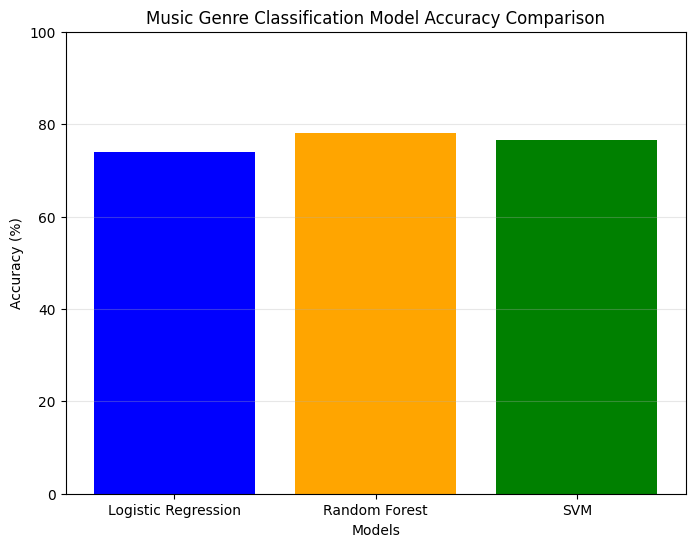

In [25]:
# Models and their accuracies
models = ['Logistic Regression', 'Random Forest', 'SVM']
accuracies = [
    l_acc * 100,   # Logistic Regression accuracy
    r_acc * 100,   # Random Forest accuracy
    s_acc * 100     # SVM accuracy
]

# Plot bar chart
plt.figure(figsize=(8,6))
plt.bar(models, accuracies, color=['blue', 'orange', 'green'])
plt.ylabel('Accuracy (%)')
plt.xlabel('Models')
plt.title('Music Genre Classification Model Accuracy Comparison')
plt.ylim(0, 100)
plt.grid(alpha=0.3, axis='y')
plt.show()


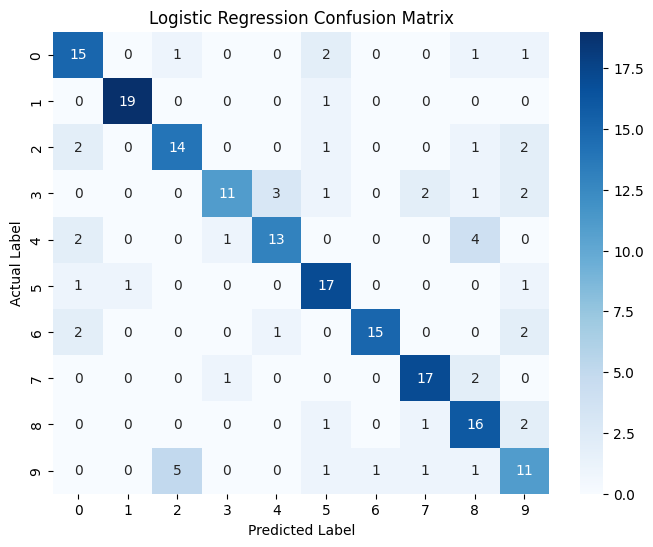

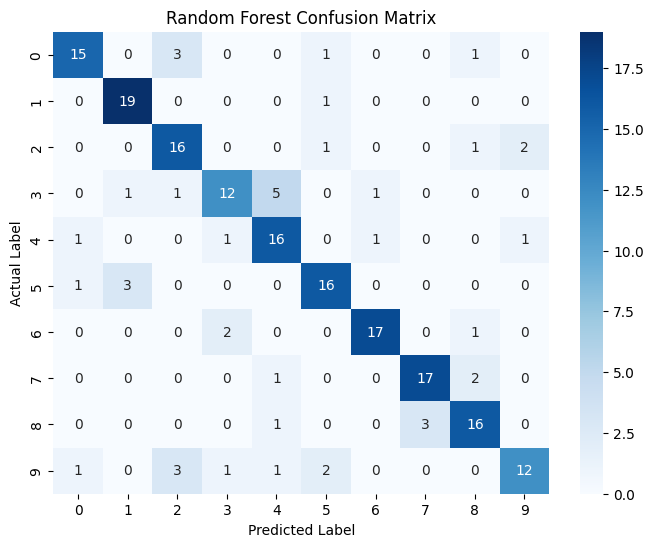

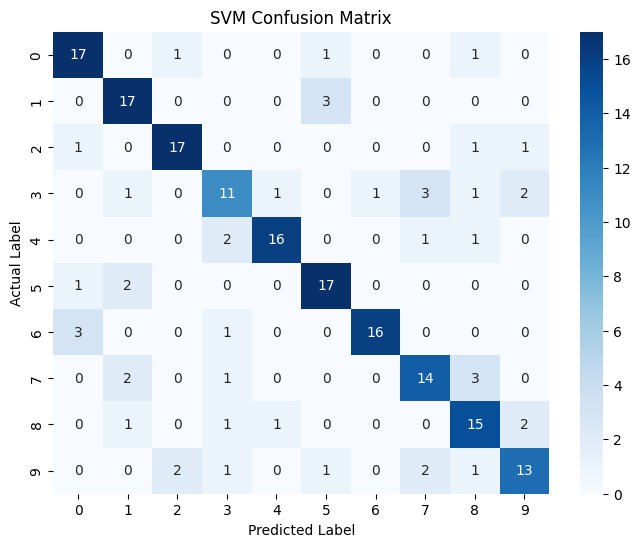

In [26]:
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.show()

plot_confusion_matrix(l_con, "Logistic Regression")
plot_confusion_matrix(r_con, "Random Forest")
plot_confusion_matrix(s_con, "SVM")
   